# 03 · Available context is not observed context

## Goal
Trace a fixed scan and a scripted selective policy over five manifest records. Neither path calls a language model.

**Status:** worked example prepared by Codex; learner understanding unassessed. No API calls.

## Setup
Run top to bottom. All examples are synthetic unless explicitly labelled as public evidence.

In [1]:
from pathlib import Path
import sys, json, tempfile
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'signal_lab').is_dir(), 'Run from the companion root or notebooks directory'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (8, 4.2), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})


## Steps

### 1. Compare the two access policies

In [2]:
from signal_lab.investigation import investigate
fixed=investigate('fixed'); selective=investigate()
pd.DataFrame([{k:r[k] for k in ['mode','complete_for_question','manifest_records_seen','manifest_size','change']} for r in [fixed,selective]])

,mode,complete_for_question,manifest_records_seen,manifest_size,change
0,fixed,True,5,5,stable -> weakening
1,adaptive-fixture,True,2,5,stable -> weakening


### 2. Observe the context boundary

In [3]:
pd.DataFrame(selective['trace'])

,document,observation
0,a-current,Demand is weakening.
1,a-previous,Demand is stable.


### 3. Missing evidence must survive synthesis

In [4]:
missing=investigate(issuer='B')
assert missing['change'] is None
pd.DataFrame([{'issuer':missing['issuer'],'complete':missing['complete_for_question'],'missing':', '.join(missing['missing'])}])

,issuer,complete,missing
0,B,False,b-previous


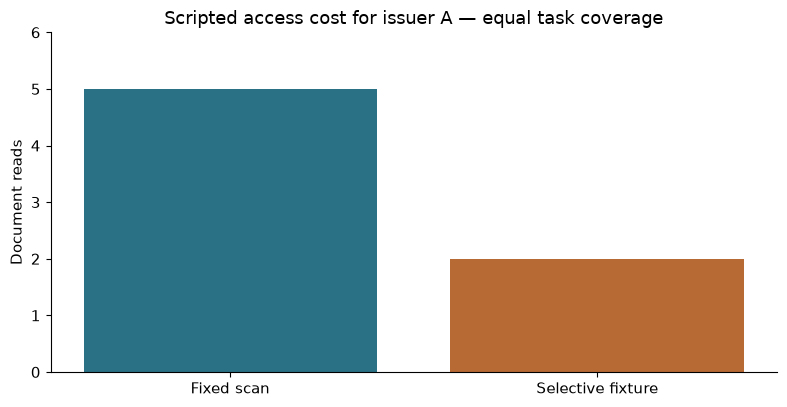

In [5]:
plt.bar(['Fixed scan','Selective fixture'],[len(fixed['trace']),len(selective['trace'])],color=['#2b7186','#b86a35'])
plt.ylim(0,6);plt.ylabel('Document reads');plt.title('Scripted access cost for issuer A — equal task coverage')
plt.tight_layout();plt.show()

## Checks
Archive coverage and question coverage differ. The missing document remains explicit. The policy is prewritten; no RLM-quality or efficiency claim follows.

## Next Steps
Optional: draw which observations a real controller would receive before choosing each read. Discuss a question for which the selective policy would miss necessary evidence.

**Low energy:** stop here. The checkpoint is optional; reading the worked output does not update mastery.